# Working with MNE and EEG-BIDS Part 1

In this notebook we will go over:


*   Data exploration
*   Cropping and filtering
*   EEG-BIDS



# Import packages

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import pathlib
import mne
import mne_bids

Ensure Matplotlib uses the `Qt5Agg` backend, which is the best choice for MNE-Python's interactive plotting functions.
> That for some reason never works on my machines, Winodws or Mac... Personal opinion: use EEGLAB and ERPLAB for raw / epoched / averaged waveform visuliazation.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃 

In [2]:
# depending on your sys / env, or whatever cursed combo of the two...
try:
    matplotlib.use('Qt5Agg')
except ImportError as e:
    print(f"{e}\n\n... Stop trying to solve this problem; it's not the main point of this module.\n- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃")
else:
    %matplotlib qt

Failed to import any of the following Qt binding modules: PyQt5, PySide2

... Stop trying to solve this problem; it's not the main point of this module.
- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃


# Data Exploration

## Load the dataset

In this tutorial, we will work with the EEG data in the MNE [sample dataset](https://mne.tools/dev/overview/datasets_index.html#contents-of-the-data-set)

The full dataset may take too long to download. For this tutorial, download the raw file from [this link] (https://drive.google.com/file/d/1-RSyaXp2Chx0zLuaAnlgK8o1VMo3enx8/view?usp=share_link) to your local directory.

## Read the raw data
> Personal opinion: for <i>simple data inspection only</i>, do `preload=False`. But since we're doing ICA, filtering, projections, etc., in this exercise, `preload=True` is faster.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [3]:
raw_path = "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_path, verbose=False, preload=True); # MNE doc: "Preload data into memory for data manipulation and faster indexing.
                                                                  # If True, the data will be preloaded into memory
                                                                  # (fast, requires large amount of memory).""
print(f"Type of raw: {type(raw)}")
print(f"Raw data shape (n_channels, n_times) = {raw.get_data().shape})")
print("raw.info")
display(raw.info)

Type of raw: <class 'mne.io.fiff.raw.Raw'>
Raw data shape (n_channels, n_times) = (376, 166800))
raw.info


<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>

## Let's visualize the raw data!

In [136]:
set(raw.get_channel_types())

{'eeg', 'eog', 'grad', 'mag', 'stim'}

In [11]:
# I personally find the default raw.plot() to be very slow and unresponsive...
# raw.plot();

# Export too EEGLAB format for better visualization.
eeglab_path = pathlib.Path("sample_audvis_raw.set")

eeg_and_eog_channels = tuple([ch for ch, t in zip(raw.ch_names, raw.get_channel_types()) if t in ["eeg", "eog"]])
mne.export.export_raw(eeglab_path, raw.copy().pick(eeg_and_eog_channels),
                      fmt="eeglab", verbose=False, overwrite=True)

!! insert screenshot
> there are no event markers when you export as SET (because there' sno annotations)

## Extract events from the `STIM` channels

In this experiment, checkerboard patterns were presented to the subject into the left and right visual field, interspersed by tones to the left or right ear. The interval between the stimuli was 750 ms. Occasionally a smiley face was presented at the center of the visual field. The subject was asked to press a key with the right index finger as soon as possible after the appearance of the face.

We can extract information about the events in this task from the raw data.

In [12]:
events = mne.find_events(raw)
print(f">> Type of events: {type(events)}\n")

# create event id and label them according to the task paradigm.
event_id = {
    "Auditory/Left": 1,
    "Auditory/Right": 2,
    "Visual/Left": 3,
    "Visual/Right": 4,
    "Smiley": 5,
    "Button": 32
}

print(raw.annotations)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
>> Type of events: <class 'numpy.ndarray'>

<Annotations | 0 segments>


In [13]:
annot = mne.annotations_from_events(events,
                                    event_desc={v:k for k,v in event_id.items()},
                                    sfreq=raw.info["sfreq"])
for a in annot[:5]:
    print(a)

raw_obj = mne.io.RawArray(raw.get_data(), info=raw.info)
raw_obj.set_annotations(annot)

# now export again, event markers will show in eeglab
# however, please note that eeglab takes integer event codes (they are currently strings)
mne.export.export_raw(eeglab_path, raw_obj.copy().pick(eeg_and_eog_channels),
                      fmt="eeglab", verbose=False, overwrite=True)

OrderedDict([('onset', np.float64(46.58058898776848)), ('duration', np.float64(0.0)), ('description', np.str_('Auditory/Right')), ('orig_time', None), ('extras', {})])
OrderedDict([('onset', np.float64(47.19329430812087)), ('duration', np.float64(0.0)), ('description', np.str_('Visual/Left')), ('orig_time', None), ('extras', {})])
OrderedDict([('onset', np.float64(47.90256731483314)), ('duration', np.float64(0.0)), ('description', np.str_('Auditory/Left')), ('orig_time', None), ('extras', {})])
OrderedDict([('onset', np.float64(48.648469443957794)), ('duration', np.float64(0.0)), ('description', np.str_('Visual/Right')), ('orig_time', None), ('extras', {})])
OrderedDict([('onset', np.float64(49.36939717143764)), ('duration', np.float64(0.0)), ('description', np.str_('Auditory/Right')), ('orig_time', None), ('extras', {})])
Creating RawArray with float64 data, n_channels=376, n_times=166800
    Range : 0 ... 166799 =      0.000 ...   277.714 secs
Ready.


/var/folders/n3/nqqvqq1n0jx25dfd3nyxjxmh0000gn/T/ipykernel_3593/1733542495.py:8: RuntimeWarning: Omitted 1 annotation(s) that were outside data range.
  raw_obj.set_annotations(annot)


### add screenshot for the raw plot from eeglab with event markers

In [14]:
# annotations is a Python iterable of Ordered Dicts
print(f"Each dict has keys: {annot[0].keys()}")

# lets' organize the first few into a pandas data frame for better visualization
import pandas as pd
df_annot = pd.DataFrame(raw_obj.annotations)
display(df_annot.head())
print("...")
display(df_annot.tail())
print(f"{len(df_annot)} Rows x {len(df_annot.columns)} Columns")

Each dict has keys: odict_keys(['onset', 'duration', 'description', 'orig_time', 'extras'])


,onset,duration,description,orig_time,extras
0,46.580589,0.0,Auditory/Right,2002-12-03 19:01:10.720100+00:00,[]
1,47.193294,0.0,Visual/Left,2002-12-03 19:01:10.720100+00:00,[]
2,47.902567,0.0,Auditory/Left,2002-12-03 19:01:10.720100+00:00,[]
3,48.648469,0.0,Visual/Right,2002-12-03 19:01:10.720100+00:00,[]
4,49.369397,0.0,Auditory/Right,2002-12-03 19:01:10.720100+00:00,[]


...


,onset,duration,description,orig_time,extras
314,254.447529,0.0,Visual/Right,2002-12-03 19:01:10.720100+00:00,[]
315,255.090203,0.0,Auditory/Right,2002-12-03 19:01:10.720100+00:00,[]
316,255.872735,0.0,Visual/Left,2002-12-03 19:01:10.720100+00:00,[]
317,256.537054,0.0,Auditory/Left,2002-12-03 19:01:10.720100+00:00,[]
318,257.213027,0.0,Visual/Right,2002-12-03 19:01:10.720100+00:00,[]


319 Rows x 5 Columns


We can plot when these events take place in time in the task paradigm

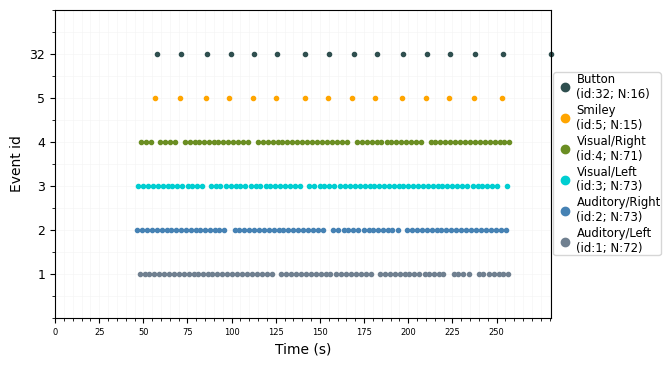

In [73]:
# yes, you can just do:
# mne.viz.plot_events(events, event_id=event_id, sfreq=raw.info['sfreq']);
# but the plot will be ugly haha

from matplotlib.ticker import AutoMinorLocator
import  numpy as np

_, axes = plt.subplots(figsize=(8, 4))
ax = axes[0] if isinstance(axes, np.ndarray) else axes
ax.tick_params(axis="y", which="major", labelsize=9)
ax.tick_params(axis="x", which="major", labelsize=6)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
ax.set_xticks(range(0, 251, 25))

fig = mne.viz.plot_events(events, event_id=event_id, sfreq=raw.info["sfreq"],
                    axes=ax, color={1:"slategray",
                                      2:"steelblue",
                                      3:"darkturquoise",
                                      4:"olivedrab",
                                      5:"orange",
                                      32:"darkslategray"},
                    show=True)

## Plot the raw data again, but add event markers

In [ ]:
# raw.plot(events=events, event_id=event_id);

## Gather some info about the data

In [126]:
# Identify bad channels labbeled during acquisition
print(f"Bad channels: {raw.info['bads']}\n")

# We can also call specific channels and their properties
print(raw.info["chs"][0])

Bad channels: ['MEG 2443', 'EEG 053']

{'scanno': 1, 'logno': 113, 'kind': 1 (FIFFV_MEG_CH), 'range': 0.00030517578125, 'cal': 3.1600000394149674e-09, 'coil_type': 3012 (FIFFV_COIL_VV_PLANAR_T1), 'loc': array([-0.1066    ,  0.0464    , -0.0604    , -0.0127    ,  0.0057    ,
       -0.99990302, -0.186801  , -0.98240298, -0.0033    , -0.98232698,
        0.18674099,  0.013541  ]), 'unit': 201 (FIFF_UNIT_T_M), 'unit_mul': 0 (FIFF_UNITM_NONE), 'ch_name': 'MEG 0113', 'coord_frame': 1 (FIFFV_COORD_DEVICE)}


> Another important thing: channel locations. You can access the channel layout by calling `Info.get_montage()`.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

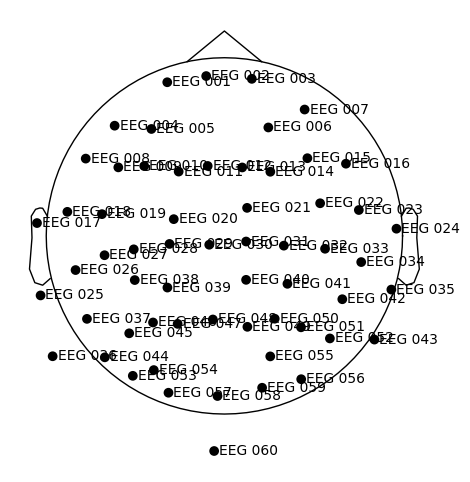

dict_keys(['ch_pos', 'coord_frame', 'nasion', 'lpa', 'rpa', 'hsp', 'hpi'])
>> Coordinate Frame: head
>> Channel Position of EEG 047
   = [-0.0377494  -0.04685587  0.11972748]


In [90]:
montage = raw.info.get_montage()

ch_positions = montage.get_positions()

_, axes = plt.subplots(figsize=(6, 6))
fig = montage.plot(kind="topomap",
             scale=0.5,
             sphere="auto", 
             axes=axes,
             show=True)
#fig_3d = montage.plot(kind="3d", show=False)
#fig_3d.gca().view_init(azim=70, elev=15)

print(ch_positions.keys())
print(f">> Coordinate Frame: {ch_positions['coord_frame']}")
print(f">> Channel Position of EEG 047\n   = {ch_positions['ch_pos']['EEG 047']}")


## Select only a subset of the channels

> Why `raw.copy()`? Because Python object mutability is cursed. See the cell below.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [113]:
import copy

lst1 = [[1, 2, 3], "Python"]
lst2 = lst1
lst3 = copy.copy(lst1)
lst4 = copy.deepcopy(lst1)

print(f"OUTER IDS:\n  id(lst1)={id(lst1)}; id(lst2)={id(lst2)}; id(lst3)={id(lst3)}; id(lst4)={id(lst4)}")
print(f"INNER IDS:\n  id(lst1[0])={id(lst1[0])}; id(lst2[0])={id(lst2[0])}; id(lst3[0])={id(lst3[0])}; id(lst4[0])={id(lst4[0])}\n")

lst1.append(100)
print(f"After lst1.append(100):\n  lst1={lst1}\n  lst2={lst2}\n  lst3={lst3}\n  lst4={lst4}\n")

lst1[0].sort(reverse=True)
print(f"After lst1[0].sort(reverse=True):\n  lst1={lst1}\n  lst2={lst2}\n  lst3={lst3}\n  lst4={lst4}\n")

lst2[0] = ['MNE']
print(f"After lst2[0]='MNE':\n  lst1={lst1}\n  lst2={lst2}\n  lst3={lst3}\n  lst4={lst4}\n")

# slicing is also a shallow copy of the outer list
lst5 = lst1[:2]
print(f"OUTER IDS:\n  id(lst1)={id(lst1)}; id(lst5)={id(lst5)}")
print(f"INNER IDS:\n  id(lst1[0])={id(lst1[0])}; id(lst5[0])={id(lst5[0])}\n")

lst1[0].append("is fun!")
print(f"After lst1[0].append('is fun!'):\n  lst={lst1}\n  lst5={lst5}")


OUTER IDS:
  id(lst1)=5322611840; id(lst2)=5322611840; id(lst3)=5322605184; id(lst4)=5322615744
INNER IDS:
  id(lst1[0])=5322613184; id(lst2[0])=5322613184; id(lst3[0])=5322613184; id(lst4[0])=5322586112

After lst1.append(100):
  lst1=[[1, 2, 3], 'Python', 100]
  lst2=[[1, 2, 3], 'Python', 100]
  lst3=[[1, 2, 3], 'Python']
  lst4=[[1, 2, 3], 'Python']

After lst1[0].sort(reverse=True):
  lst1=[[3, 2, 1], 'Python', 100]
  lst2=[[3, 2, 1], 'Python', 100]
  lst3=[[3, 2, 1], 'Python']
  lst4=[[1, 2, 3], 'Python']

After lst2[0]='MNE':
  lst1=[['MNE'], 'Python', 100]
  lst2=[['MNE'], 'Python', 100]
  lst3=[[3, 2, 1], 'Python']
  lst4=[[1, 2, 3], 'Python']

OUTER IDS:
  id(lst1)=5322611840; id(lst5)=5322613568
INNER IDS:
  id(lst1[0])=5322612032; id(lst5[0])=5322612032

After lst1[0].append('is fun!'):
  lst=[['MNE', 'is fun!'], 'Python', 100]
  lst5=[['MNE', 'is fun!'], 'Python']


> For immutable objects like <i>ints / strings / tuples</i>, "deep vs shallow" often doesn't visibly matter much, because mutating them is not the issue. This concept matters most for mutable nested objects:<strong><br><br><i>lists</i><br><i>dicts</i><br>sets<br><i>custom objects</i></strong><br><br>... For <i>NumPy arrays</i>, <i>Pandas Series / DataFrames</i>, and <i>MNE objects</i>, same high-level mutability idea, but much more complex.<br><br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [ ]:
raw_equal = raw
raw_eeg = raw.copy()
print(f"id(raw)={id(raw)}; id(raw_equal)={id(raw_equal)}; id(raw_eeg)={id(raw_eeg)}\n")

# raw_eeg.pick_types(meg=False, eeg=True, eog=True, exclude=[]) <- legacy function
raw_eeg.pick(["eeg","eog"], exclude=[]) # exclude is for
                                        # "Set of channels to exclude, only used when picking based on types"
print(f">> EOG +EEG channels = {len(raw_eeg.ch_names)} channels")

# channel descriptions 
df_ch_desc = raw_eeg.describe(data_frame=True)
display(df_ch_desc.head())

id(raw)=4999227344; id(raw_equal)=4999227344; id(raw_eeg)=4971222096

>> EOG +EEG channels = 61 channels


,name,type,unit,min,Q1,median,Q3,max
ch,,,,,,,,
0,EEG 001,eeg,V,-0.000299,-0.000003,0.000008,0.000020,0.000300
1,EEG 002,eeg,V,-0.000250,0.000038,0.000048,0.000059,0.000333
2,EEG 003,eeg,V,-0.000248,0.000038,0.000048,0.000059,0.000337
3,EEG 004,eeg,V,-0.000043,0.000179,0.000192,0.000205,0.000427
4,EEG 005,eeg,V,-0.000174,0.000060,0.000070,0.000081,0.000298


## Visualizing sensor locations and marking channels as bad
Mark an additional EEG channel as bad and view the topoplot.

Actual bads: ['MEG 2443', 'EEG 053']
After we added fake bads: ['MEG 2443', 'EEG 053', 'EEG 051', 'EEG 047']


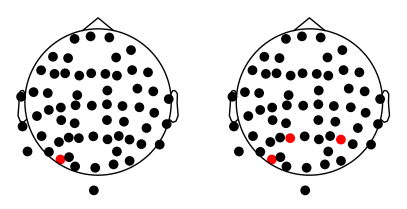

In [171]:
# In 2D
raw_eeg = raw.copy()

_, axes = plt.subplots(1, 2, figsize=(5, 5))
raw_eeg.plot_sensors(ch_type="eeg", axes=axes[0], show=False);

info = raw_eeg.info
print(f"Actual bads: {info['bads']}")
info["bads"] += ["EEG 051", "EEG 047"]
print(f"After we added fake bads: {info['bads']}")
raw_eeg.plot_sensors(ch_type="eeg", axes=axes[1], show=True);


In [ ]:
# It's a "supposed" 3D plot getting squashed into 2D in my opinion lol -- pretty ugly (means very ugly, not pretty... English is werid...)
# raw_eeg.plot_sensors(kind="3d", ch_type="eeg", show=True);

# Cropping and filtering the data

## Cropping

This EEG datset contains around 278 seconds of data. We can use only the first 100 seconds for analysis by cropping the data.

In [397]:
print(f"Type of raw.times = {type(raw.times)}")
print(f"length of raw.times = {len(raw.times)}")
print(f"last 10 time points:\n  {raw.times[-10:]}\n")

data = raw.get_data()  # default unit is V (volts)
n_channels, n_times = data.shape
print(f"Type of data = {type(data)}")
print(f"Shape of data (n_channels, n_times) = {n_channels, n_times}")
print(f"length of raw.times = n_times?   {len(raw.times) == n_times}\n")

# we can also get only the specific types of channels and change the units:
data_eeg = raw.copy().get_data(picks=["eeg", "eog"], units={"eeg": "uV", "eog": "uV"})
print(f"Shape of data_eeg = {data_eeg.shape}")

# our sampling rate is 600.61 Hz, let's verify it matches the time points
# assert means "if True, code will run fine; if False, throw an assertion error"
assert (raw.times[-1] * raw.info["sfreq"] - n_times) < 1e-5   # <- a tolerance threshold as machines have floating point precision errors

Type of raw.times = <class 'numpy.ndarray'>
length of raw.times = 166800
last 10 time points:
  [277.69869669 277.70036165 277.70202661 277.70369157 277.70535653
 277.70702149 277.70868645 277.71035141 277.71201637 277.71368133]

Type of data = <class 'numpy.ndarray'>
Shape of data (n_channels, n_times) = (376, 166800)
length of raw.times = n_times?   True

Shape of data_eeg = (61, 166800)


It's best to make a copy of the loaded data first before cropping.

In [18]:
# raw_cropped = raw.copy()
#raw_cropped = raw_cropped.crop(tmax=100)

# just do, in one line
raw_cropped = raw.copy().crop(tmax=100) # by default this includes tmax; can change using include_tmax=False
print(f"last 10 time points:\n  {raw_cropped.times[-10:]}\n")

last 10 time points:
  [99.9841845  99.98584947 99.98751443 99.98917939 99.99084435 99.99250931
 99.99417427 99.99583923 99.99750419 99.99916915]



## Filtering

We can also filter to get a specific frequency range

When we plot the power spectrum we can see frequencies ranging upto 300 Hz. 

> I spent four years in grad school understanding this plot (hello, Fourier analysis)... So I'm gonna do the ugly math here: Manually decompose the time domain signals into frequency bins. This way, we actually know what we're doing... instead of just looking at those green speghatti lines :P<br><br>NOTE that this will <strong>not</strong> be identical to MNE's `compute_psd.plot()` due to segment lengths, overlap ratio, padding, etc. Just wanted to demonstrate what <i>PSD (power spectrum density)</i> actually is by coomputing it from scratch using `Numpy` and `Scipy` only.<br><br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [25]:
from scipy.signal import get_window, welch
from scipy.fft import rfft, rfftfreq

# start from selecting one channel "EEG 047"
# also using uV because in V the numbers are too samll and less humanly interpretable in plots
chan_idx = "047"
x= raw_cropped.get_data(units={"eeg": "uV", "eog": "uV"})[raw_cropped.ch_names.index(f"EEG {chan_idx}")]
print(f"1D time series shape (n_times,) = {x.shape}")    

length, overlap, sfreq = 2, 0.5, raw_cropped.info["sfreq"]   # window length = 2 secs with 50% overlap
Nx = length*int(sfreq)
step_size = int(Nx * (1 - overlap))
nsegs = (x.shape[0] - Nx) // step_size + 1
print(f"Number of windows = {nsegs}")
w = get_window("hann", Nx, fftbins=True) # fftbins if True (default), create a periodic window, 
print(f"Each window shape (n_samples_per_window) = {w.shape}")

# multiply by hann window to reduce edge discontinuities and remove per-window mean (remove DC offset)
x_detrended = np.array([x[step_size * i: step_size * i + Nx] - np.mean(x[step_size * i: step_size * i + Nx])
                       for i in range(nsegs)])
windowed = np.multiply(np.tile(w, (99, 1)), x_detrended) # multiplication is element-wise
print(f"Input array shape to real-valued FFT: {windowed.shape}")

last_idx = Nx + step_size * (nsegs - 1)
n_cutoffs = x.shape[0] - last_idx
print(f"Number indices being cut-off: {n_cutoffs} samples = {round(n_cutoffs/sfreq, 2)} secs")

# Compute the 1-D n-point discrete Fourier Transform (DFT) of a real-valued array
# by means of an efficient algorithm called the Fast Fourier Transform (FFT)
delta_f = sfreq / Nx
print(f"Nyquist = {round(sfreq/2, 2)} Hz; frequency bin size = {Nx//2 + 1} Hz")
print(f"  -> Total number of bins = {int(1 + (sfreq/2) / delta_f)}")
coeffs = rfft(windowed, workers=-1) # axis=-1 by default; norm{"backward", "ortho", "forward"}, default is "backward"
print(f"\nDFT coefficient shape (n_windows, n_freq_bins) = {coeffs.shape}")
print(f"  -> coeffs[47][47] = {coeffs[47][47]}")

# power = coefficient (which are complex numbers) magnittude squared
power = np.abs(coeffs) ** 2                     # <- ChatGPT suggested this, cleaner than my `power = np.abs(np.multiply(coeffs, np.conjugate(coeffs)))``
freqs = rfftfreq(Nx, d=1/sfreq)                 # bin centers
times = (np.arange(nsegs) * step_size + Nx/2)/sfreq   # window centers in secs
# plot power.T as time × frequency.

# Welch: average over windows
scale_factor = sfreq * np.sum(np.abs(w)**2)
scaled_power = np.concatenate([power[:, 0].reshape(-1, 1),
                               2 * power[:, 1:-1],
                               power[:, -1].reshape(-1, 1)], axis=-1)/scale_factor  # one sided since signals are real
psd = scaled_power.mean(axis=0)

# Finally we check our manual implementation against scipy.signal.welch
f, Pxx = welch(x, fs=sfreq,
             window=w,
             nperseg=Nx,
             noverlap=Nx*overlap,
             nfft=None,
             detrend="constant",  # if 'constant', only the mean of data is subtracted.
             return_onesided=True,
             scaling="density",
             average="mean")
print(f"\n\n>> Is our manual implementation nearly identical to Scipy abrrign floating point erros: {np.allclose(psd, Pxx) and (f==freqs).all()}")


1D time series shape (n_times,) = (60062,)
Number of windows = 99
Each window shape (n_samples_per_window) = (1200,)
Input array shape to real-valued FFT: (99, 1200)
Number indices being cut-off: 62 samples = 0.1 secs
Nyquist = 300.31 Hz; frequency bin size = 601 Hz
  -> Total number of bins = 601

DFT coefficient shape (n_windows, n_freq_bins) = (99, 601)
  -> coeffs[47][47] = (-46.31991910417827-226.6584993998171j)


>> Is our manual implementation nearly identical to Scipy abrrign floating point erros: True


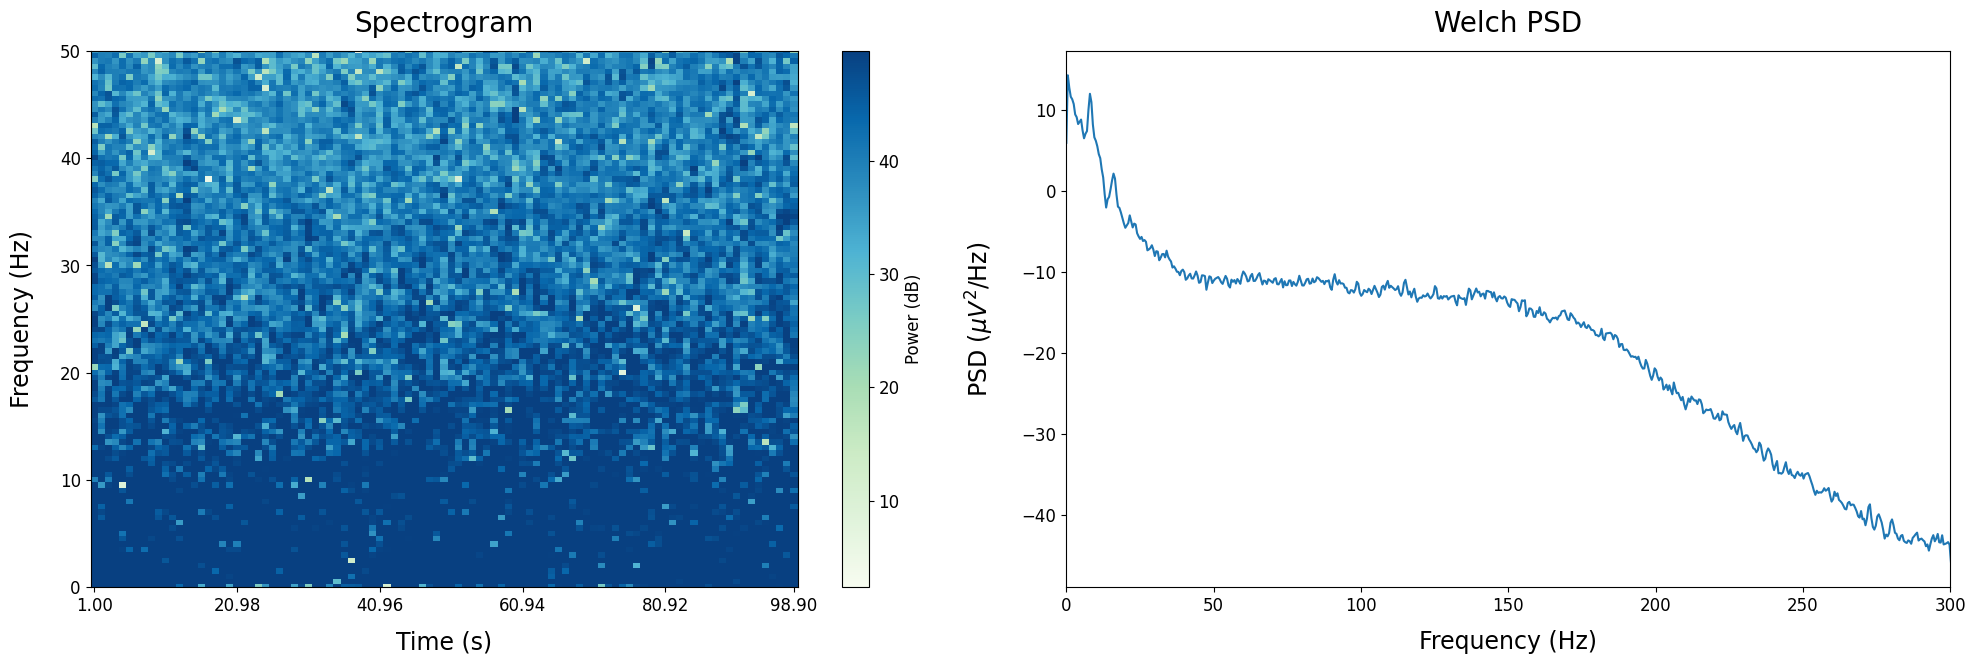

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

log_power = 10 * np.log10(power.T + 1e-12)
vmin = np.percentile(log_power, 5)
vmax = np.percentile(log_power, 95)
pcm = axes[0].pcolormesh(
    times,
    freqs,
    log_power,
    vmin=vmin,
    vmax=vmax,
    shading="auto",
    cmap="GnBu"
);
axes[0].set_ylim(0, 50) # EEG-friendly first pass
axes[0].set_xticks(np.array([times[0],times[20],times[40],times[60],times[80],times[-1]]))
axes[0].set_xlabel("Time (s)", fontsize=17)
axes[0].set_ylabel("Frequency (Hz)", fontsize=17)
axes[0].set_title("Spectrogram", fontsize=20, y=1.02)
cbar = fig.colorbar(pcm)
cbar.set_label(label="Power (dB)", fontsize=12)
cbar.ax.tick_params(labelsize=12)

axes[1].plot(freqs, 10 * np.log10(psd + 1e-12), linewidth=1.5)
axes[1].set_xlim(0, 300)
axes[1].set_xlabel("Frequency (Hz)", fontsize=17)
axes[1].set_ylabel(r"PSD ($\mu V^2$/Hz)", fontsize=17)
axes[1].set_title("Welch PSD", fontsize=20, y=1.02)

for ax in axes:
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.xaxis.set_label_coords(0.5, -0.08)
    ax.yaxis.set_label_coords(-0.08, 0.5)

fig.tight_layout(pad=2)
plt.show()

Shape of PSD array = (n_channels, n_freq_bins) = (59, 601)


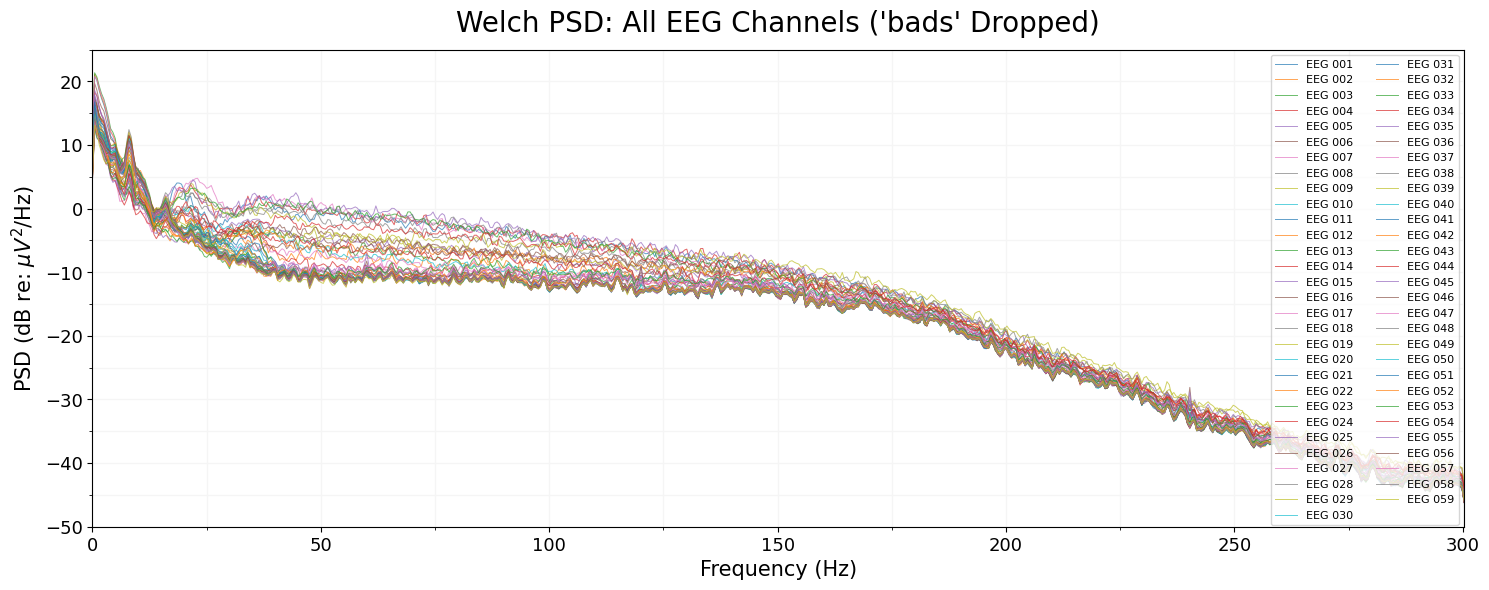

In [29]:
# for all eeg channels, we loop using a list comprehension
def my_plot_psd(raw, figsize=(15,6), legend: bool=True, display_shape=False, title: str | None= None,
                xlim: tuple| None = None, ylim: tuple| None = None ,
                picks: str | list[str] = None, units: str | dict = None, drop_bads: bool=True):
    if drop_bads:
        raw_dropped = raw.copy().drop_channels(raw.info["bads"]) # remove bad channels
    psds = np.array([welch(x, fs=sfreq,
                 window=w,
                 nperseg=Nx,
                 noverlap=Nx*overlap,
                 nfft=None,
                 detrend="constant",  # remove DC offset
                 return_onesided=True,
                 scaling="density",
          average="mean")[1]
          for x in raw_dropped.copy().get_data(picks=picks,
                                               units=units)])
    # get freqency axis for plotting
    freqs = welch(raw_dropped.copy().get_data(picks=picks,
                                          units=units)[0],
                 fs=sfreq,
                 window=w,
                 nperseg=Nx,
                 noverlap=Nx*overlap,
                 nfft=None,
                 detrend="constant",  # remove DC offset
                 return_onesided=True,
                 scaling="density",
                 average="mean")[0]
    if display_shape:
        print(f"Shape of PSD array = (n_channels, n_freq_bins) = {psds.shape}")

    ch_names = raw_cropped.copy().pick("eeg").ch_names

    fig, ax = plt.subplots(figsize=figsize)
    for psd, ch in zip(psds, ch_names):
        ax.plot(freqs, 10 * np.log10(psd + 1e-12), label=ch, alpha=0.7, linewidth=0.7)
    if xlim is None:
        xlim = (0, raw.info["sfreq"]/2)
    if ylim is None:
        ylim = (-50, 25)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.tick_params(axis="both", which="major", labelsize=13)
    ax.set_xlabel("Frequency (Hz)", fontsize=15)
    ax.set_ylabel(r"PSD (dB re: $\mu V^2$/Hz)", fontsize=15)
    ax.set_title(title, fontsize=20, y=1.02)
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(linewidth=1, color="whitesmoke", which="major", zorder=1)
    ax.grid(linewidth=1, color="whitesmoke", which="minor", zorder=0)
    if legend:
        ax.legend(fontsize=8, ncol=2)

    fig.tight_layout()
    plt.show()
    return freqs, psds

_ = my_plot_psd(raw_cropped, title = "Welch PSD: All EEG Channels ('bads' Dropped)",
                picks="eeg", units="uV", display_shape=True)

Let's say we only want to look at signals between 0.1 and 40 Hz to focus only on some of the brain-related activity.

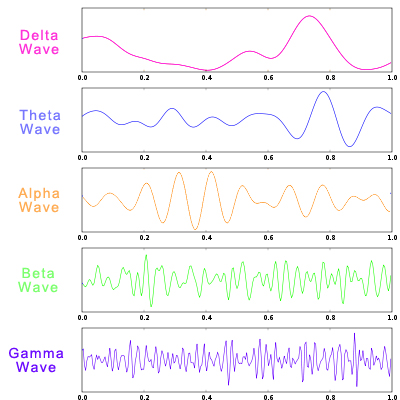

Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

Setting up band-pass filter from 1 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 32 (effective, after forward-backward)
- Cutoffs at 1.00, 40.00 Hz: -6.02, -6.02 dB



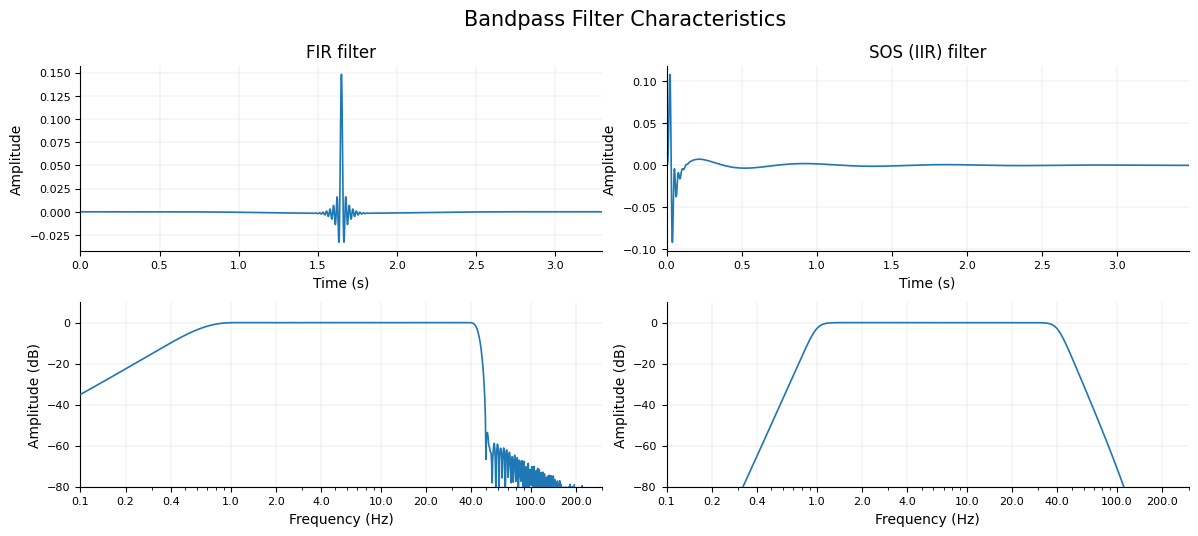

In [20]:
# Filter data using a bandpass filter 1-40 Hz
raw_cropped_dropped = raw_cropped.copy().drop_channels(raw_cropped.info["bads"])
sfreq = raw_cropped_dropped.info["sfreq"]

# Create FIR filter parameters for plotting (note that this does NOT filter the data yet)
bandpass_fir = mne.filter.create_filter(
    data=raw_cropped_dropped.get_data(picks=["eeg", "eog"],
                                      units={"eeg": "uV", "eog": "uV"}),
    sfreq=sfreq,
    l_freq=1, h_freq=40,
    method="fir",
    fir_window="hamming",
    fir_design="firwin",
    verbose=True
)

# Create IIR Butterworth filter parameters for plotting and compare with FIR
bandpass_iir_butter = mne.filter.create_filter(
    data=raw_cropped_dropped.get_data(picks=["eeg", "eog"],
                                      units={"eeg": "uV", "eog": "uV"}),
    sfreq=sfreq,
    l_freq=1, h_freq=40,
    method="iir",
    iir_params={"order": 8, "ftype": "butter"},
    verbose=True
)

fig, axes = plt.subplots(2, 2, figsize=(12, 5))
for ax in axes.flatten():
    ax.tick_params(axis="both", which="major", labelsize=8)
fig.tight_layout(pad=2)
fig.suptitle("Bandpass Filter Characteristics", fontsize=15, y=1.05)

mne.viz.plot_filter(bandpass_fir, sfreq,
                    flim=(0.1, 300),
                    plot=("time", "magnitude"),
                    axes = [axes[0][0], axes[1][0]],
                    show=False);
mne.viz.plot_filter(bandpass_iir_butter, sfreq,
                    flim=(0.1, 300),
                    plot=("time", "magnitude"),
                    axes = [axes[0][1], axes[1][1]],
                    show=True);

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).
Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


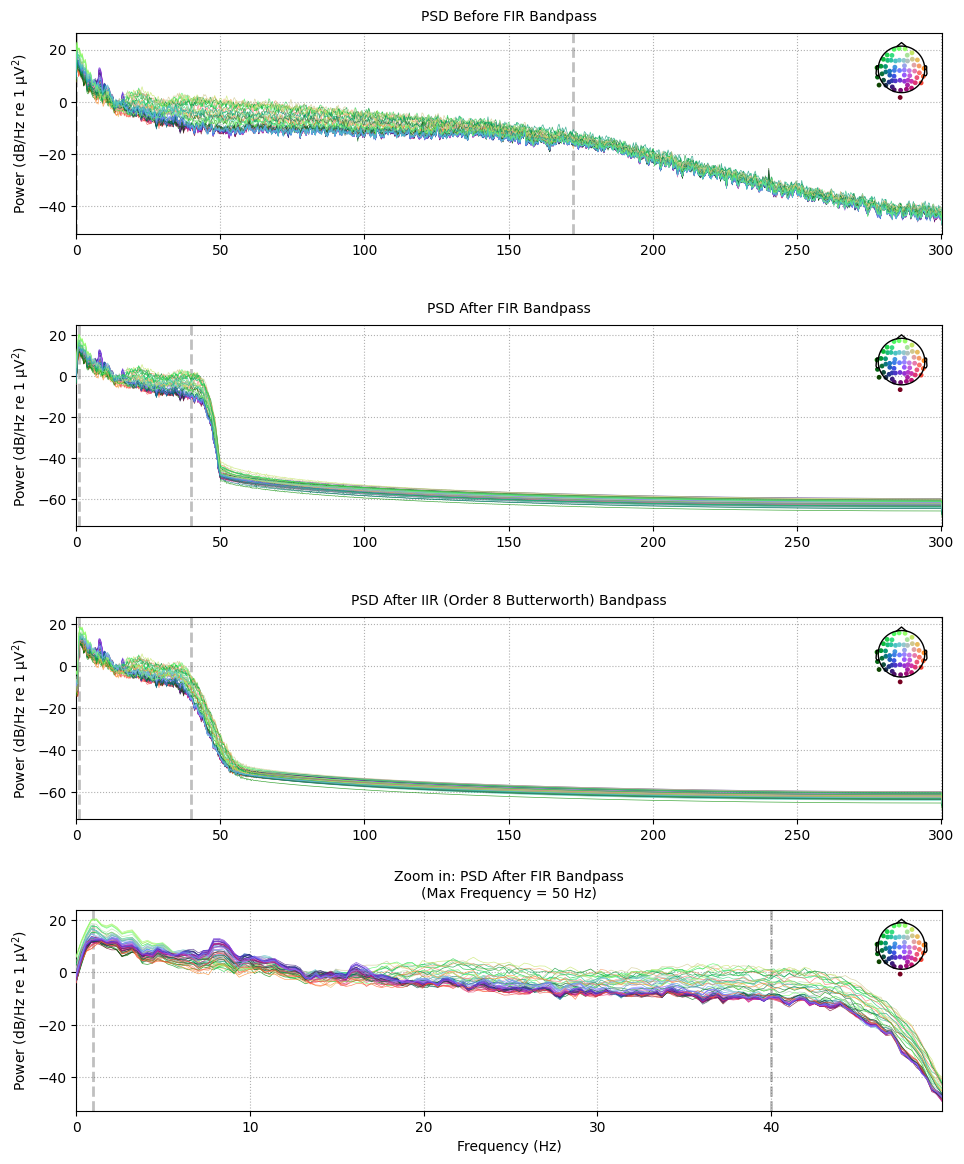

In [21]:
import warnings
warnings.filterwarnings("ignore")

raw_cropped_dropped_fir = raw_cropped_dropped.copy().filter(l_freq=1, h_freq=40,
                                                            method="fir",
                                                            verbose=True)
raw_cropped_dropped_iir = raw_cropped_dropped.copy().filter(l_freq=1, h_freq=40,
                                                            method="iir",
                                                            iir_params=bandpass_iir_butter,
                                                            verbose=True)

# and yes, of course MNE makes plotting a lot easier... no manual Welch implementation XD
# note that raw.plot_psd() is a legacy function; please use raw.compute_psd().plot()

fig, axes = plt.subplots(4, 1, figsize=(10,12))
raw_cropped_dropped.compute_psd(method="welch").plot(axes=axes[0], picks=["eeg"], show=False);
raw_cropped_dropped_fir.compute_psd(method="welch").plot(axes=axes[1], picks=["eeg"], show=False);
raw_cropped_dropped_iir.compute_psd(method="welch").plot(axes=axes[2], picks=["eeg"], show=False);
raw_cropped_dropped_fir.compute_psd(fmax=50).plot(axes=axes[3], picks=["eeg"], show=False);

axes[0].set_title("PSD Before FIR Bandpass", y=1.02, fontsize=10)
axes[1].set_title("PSD After FIR Bandpass", y=1.02, fontsize=10)
axes[2].set_title("PSD After IIR (Order 8 Butterworth) Bandpass", y=1.02, fontsize=10)
axes[3].set_title("Zoom in: PSD After FIR Bandpass\n(Max Frequency = 50 Hz)", y=1.02, fontsize=10)
axes[3].set_xlabel("Frequency (Hz)")
fig.tight_layout(pad=2)
plt.show()

warnings.resetwarnings()
    

# Saving the data in BIDS format


Neuroimaging experiments result in complicated data that can be arranged in many different ways. So far there is no consensus how to organize and share data obtained in neuroimaging experiments. Even two researchers working in the same lab can opt to arrange their data in a different way. Lack of consensus (or a standard) leads to misunderstandings and time wasted on rearranging data or rewriting scripts expecting certain structure.

BIDS, the Brain Imaging Data Structure, is a standard that describes how to organize neuroimaging and electrophysiological data. In particular, it defines:



*   which file formats to use
*   how to name your files
* where to place your files within a directory structure
* what additional metadata to store

The complete set of rules is written down in the [BIDS specification](https://bids-specification.readthedocs.io/en/stable/).

Here we use an extension to BIDS for electroencephalography (EEG) data, **EEG-BIDS**.

**[MNE-BIDS](https://mne.tools/mne-bids/stable/index.html)** is a Python package that allows you to read and write BIDS-compatible datasets with the help of MNE-Python.

## Write the raw data to BIDS!

We need to specify the power line frequency.

> The data actually doesn't show the typical power line noise pattern... There should be a spike at 60 Hz. For example, this is a subject's data from my lab.<br>- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


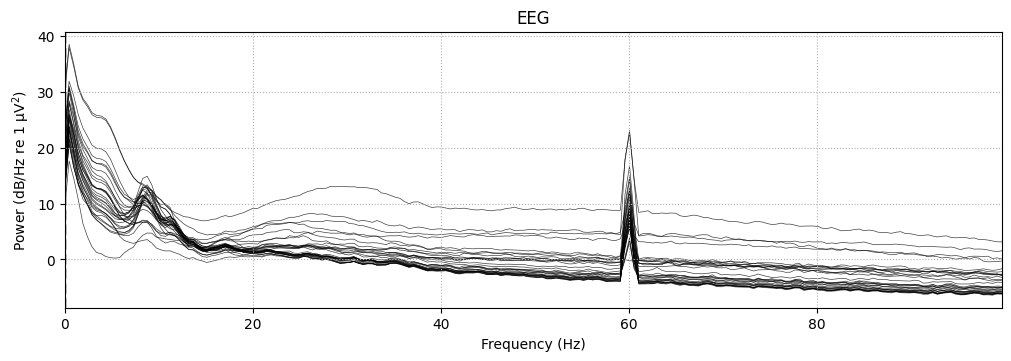

In [22]:
warnings.filterwarnings("ignore")

# our data doesn't have channel locations set (needs info.set_montage())
# so the plot output is grey scale with no topo in top right
my_raw = mne.io.read_raw("subj020.set", verbose=False)
my_raw.compute_psd(method="welch", fmax=100).plot(show=True);

In [7]:
# Specify the power line frequency as that is not included in the raw info
# Filter again without dropping bads
import os
from IPython.display import clear_output
import time
#PROJECT_FOLDER = ""
#if os.get_cwd() != PROJECT_FOLDER:  <- make sure you are in the right folder
#    os.chdir(PROJECT_FOLDER) 

raw_cropped_filtered = raw_cropped.copy().filter(l_freq=1, h_freq=40,
                                                 method="fir",
                                                 verbose=True)
if raw_cropped_filtered.info["line_freq"] is None:    
    raw_cropped_filtered.info["line_freq"] = 60

# Set the path to where it will be saved
out_path = pathlib.Path("out_data/sample_BIDS")

# Set path with data specific variables for naming directory files
bids_path = mne_bids.BIDSPath(subject="01",
                              session="01",
                              task="audiovisual",
                              run="01",
                              root=out_path)
# Write raw to BIDS!
# for some reason though, raw.annotations and events.tsv onset time doesn't match...
mne_bids.write_raw_bids(raw_cropped_filtered, bids_path=bids_path, events=events, event_id=event_id,
                        overwrite=True,format= "FIF", allow_preload=True )

clear_output(wait=True)  # clear verbose output
time.sleep(5)
mne_bids.print_dir_tree(out_path)
print("\n\n")       # print the created file & directory structure
# data summary
display(mne_bids.make_report(out_path, verbose="INFO"))  # verbose: True is the same as 'INFO', False same as 'WARNING'.

|sample_BIDS/
|--- README
|--- dataset_description.json
|--- participants.json
|--- participants.tsv
|--- sub-01/
|------ ses-01/
|--------- sub-01_ses-01_scans.tsv
|--------- meg/
|------------ sub-01_ses-01_coordsystem.json
|------------ sub-01_ses-01_task-audiovisual_run-01_channels.tsv
|------------ sub-01_ses-01_task-audiovisual_run-01_events.json
|------------ sub-01_ses-01_task-audiovisual_run-01_events.tsv
|------------ sub-01_ses-01_task-audiovisual_run-01_meg.fif
|------------ sub-01_ses-01_task-audiovisual_run-01_meg.json



Summarizing participants.tsv out_data/sample_BIDS/participants.tsv...
Summarizing scans.tsv files [PosixPath('out_data/sample_BIDS/sub-01/ses-01/sub-01_ses-01_scans.tsv')]...
The participant template found: sex were all unknown;
handedness were all unknown;
ages all unknown


' The [Unspecified] dataset was created by [Unspecified1], and [Unspecified2] and\nconforms to BIDS version 1.7.0. This report was generated with MNE-BIDS\n(https://doi.org/10.21105/joss.01896). The dataset consists of 1 participants\n(sex were all unknown; handedness were all unknown; ages all unknown) and 1\nrecording sessions: 01. Data was recorded using an MEG system (Elekta) sampled\nat 600.61 Hz with line noise at 60.0 Hz. The following software filters were\napplied during recording: SpatialCompensation. There was 1 scan in total.\nRecording durations ranged from 100.0 to 100.0 seconds (mean = 100.0, std =\n0.0), for a total of 100.0 seconds of data recorded over all scans. For each\ndataset, there were on average 376.0 (std = 0.0) recording channels per scan,\nout of which 374.0 (std = 0.0) were used in analysis (2.0 +/- 0.0 were removed\nfrom analysis).'

In [15]:
import json

EVENTS_TSV_PATH = "out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_events.tsv"
EVENTS_JSON_PATH = "out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_events.json"

json_data ={
    "onset": {
        "Description": "Onset (in seconds) of the event from the beginning of the first datapoint. Negative onsets account for events before the first stored data point.",
        "Units": "s"
    },
    "duration": {
        "Description": "Duration of the event in seconds from onset. Must be zero, positive, or 'n/a' if unavailable. A zero value indicates an impulse event. ",
        "Units": "s"
    },
    "sample": {
        "Description": "The event onset time in number of sampling points.First sample is 0."
    },
    "value": {
        "Description": "The event code (also known as trigger code or event ID) associated with the event."
    },
    "trial_type": {
        "Description": "The type, category, or name of the event."
    }
}

try:
    df_events = pd.read_csv(EVENTS_TSV_PATH, sep="\t")

except FileNotFoundError:
    print("... Manually writing our own events.tsv")
    events_cropped = mne.find_events(raw_cropped_filtered)
    df_events = df_annot.iloc[:len(events_cropped)]
    df_events = df_events.rename(columns={"description": "trial_type"})
    df_events = df_events.drop(columns=["orig_time", "extras"])
    df_events.insert(3, "value", events_cropped.T[2])
    df_events.insert(4, "sample", events_cropped.T[0])
    df_events["onset"] = df_events["onset"] - df_events["onset"][0]
    df_events["sample"] = df_events["sample"] - df_events["sample"][0]
    df_events.to_csv(EVENTS_TSV_PATH, sep="\t")
    with open(EVENTS_JSON_PATH, "w") as f:
        json.dump(json_data, f)

finally:
    display(df_events)

!ls "out_data/sample_BIDS/sub-01/ses-01/meg"

,onset,duration,trial_type,value,sample
0,3.624618,0.0,Auditory/Right,2,2177
1,4.237323,0.0,Visual/Left,3,2545
2,4.946596,0.0,Auditory/Left,1,2971
3,5.692499,0.0,Visual/Right,4,3419
4,6.413426,0.0,Auditory/Right,2,3852
...,...,...,...,...,...
142,97.643251,0.0,Auditory/Right,2,58646
143,98.395813,0.0,Smiley,5,59098
144,98.750449,0.0,Button,32,59311
145,99.063462,0.0,Auditory/Left,1,59499


sub-01_ses-01_coordsystem.json
sub-01_ses-01_task-audiovisual_run-01_channels.tsv
sub-01_ses-01_task-audiovisual_run-01_events.json
sub-01_ses-01_task-audiovisual_run-01_events.tsv
sub-01_ses-01_task-audiovisual_run-01_meg.fif
sub-01_ses-01_task-audiovisual_run-01_meg.json


## Reading BIDS data

In [516]:
bids_root = pathlib.Path('out_data/sample_BIDS')

bids_path = mne_bids.BIDSPath(subject='01',
                              session='01',
                              task='audiovisual',
                              run='01',
                              datatype='meg',
                              root=bids_root)

raw_BIDS = mne_bids.read_raw_bids(bids_path)
#raw_BIDS.plot();

Opening raw data file out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_meg.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 85861 =     42.956 ...   142.955 secs
Ready.
Reading events from out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_events.tsv.
Reading channel info from out_data/sample_BIDS/sub-01/ses-01/meg/sub-01_ses-01_task-audiovisual_run-01_channels.tsv.


# Refrences

**MNE-Python** - 
Alexandre Gramfort, Martin Luessi, Eric Larson, Denis A. Engemann, Daniel Strohmeier, Christian Brodbeck, Roman Goj, Mainak Jas, Teon Brooks, Lauri Parkkonen, and Matti S. Hämäläinen. MEG and EEG data analysis with MNE-Python. Frontiers in Neuroscience, 7(267):1–13, 2013. doi:10.3389/fnins.2013.00267.

**BIDS**
Gorgolewski, K.J., Auer, T., Calhoun, V.D., Craddock, R.C., Das, S., Duff, E.P., Flandin, G., Ghosh, S.S., Glatard, T., Halchenko, Y.O., Handwerker, D.A., Hanke, M., Keator, D., Li, X., Michael, Z., Maumet, C., Nichols, B.N., Nichols, T.E., Pellman, J., Poline, J.-B., Rokem, A., Schaefer, G., Sochat, V., Triplett, W., Turner, J.A., Varoquaux, G., Poldrack, R.A. (2016). The brain imaging data structure, a format for organizing and describing outputs of neuroimaging experiments. Scientific Data, 3 (160044). doi:10.1038/sdata.2016.44

**MNE-BIDS** - 
Appelhoff, S., Sanderson, M., Brooks, T., Vliet, M., Quentin, R., Holdgraf, C., Chaumon, M., Mikulan, E., Tavabi, K., Höchenberger, R., Welke, D., Brunner, C., Rockhill, A., Larson, E., Gramfort, A., & Jas, M. (2019). MNE-BIDS: Organizing electrophysiological data into the BIDS format and facilitating their analysis. *Journal of Open Source Software*, 4:1896. DOI: 10.21105/joss.01896

**EEG-BIDS** - Pernet, C. R., Appelhoff, S., Gorgolewski, K.J., Flandin, G., Phillips, C., Delorme, A., Oostenveld, R. (2019). EEG-BIDS, an extension to the brain imaging data structure for electroencephalography. Scientific data, 6 (103). doi:10.1038/s41597-019-0104-8

**MNE EEG-BIDS**
Niso, G., Gorgolewski, K., Bock, E. et al. MEG-BIDS, the brain imaging data structure extended to magnetoencephalography. *Sci Data* 5, 180110 (2018). https://doi.org/10.1038/sdata.2018.110



## Exercise #1

1) How many channels do you have for each type of sensors?


2) What is the sampling frequency?

3) Have the data been filtered?

4) What is the frequency of the line noise?

5) Is there any bad channel?